In [3]:
# =========================================
# 1) Cargar datos y preparar variable objetivo
# =========================================
import os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

# Semilla aleatoria para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Archivo y variable objetivo
DATA_FILE = "df_sin_outliers_categorizado.csv"   # tu archivo procesado
TARGET    = "QS109"                              # indica si tiene diabetes

# Verificar existencia del archivo
assert os.path.exists(DATA_FILE), f"No se encuentra {DATA_FILE}"

# Leer dataset
df = pd.read_csv(DATA_FILE)

# Mapear los valores de QS109: "Sí" → 1 (tiene diabetes), "No" → 0 (no tiene)
label_map = {"Tiene": 1, "No-tiene": 0}
y = df[TARGET].map(label_map).astype(int)

# Variables predictoras (todas excepto QS109)
X = df.drop(columns=[TARGET])

# Mostrar un resumen
print("Shape:", X.shape, "| Prevalencia (tiene diabetes = 1):", round((y == 1).mean(), 3))
print("Primeras etiquetas de y:", y.head().tolist())

Shape: (28828, 11) | Prevalencia (tiene diabetes = 1): 0.037
Primeras etiquetas de y: [0, 0, 0, 0, 0]


In [4]:
df

,QS23,QSSEXO,QS207C,QS208,QS213C,QS219C,QS900,QS901,QS907,QS102,QS500,QS109
0,38,Femenino,17.0,No,4.315413,6.000000,70.4,152.5,98.9,No,Sí,No-tiene
1,33,Masculino,17.0,Sí,7.000000,2.000000,76.0,158.2,100.4,No,No,No-tiene
2,30,Masculino,21.0,No,5.000000,3.253995,66.0,159.4,87.2,No,No,No-tiene
3,32,Femenino,18.0,Sí,7.000000,2.000000,72.9,157.0,91.7,No,No,No-tiene
4,34,Femenino,26.0,No,3.000000,4.000000,57.3,153.3,80.2,No,No,No-tiene
...,...,...,...,...,...,...,...,...,...,...,...,...
28823,35,Femenino,20.0,Sí,7.000000,3.000000,65.9,152.0,92.9,No,No,No-tiene
28824,15,Masculino,14.0,Sí,2.000000,3.000000,54.5,164.0,69.9,No,No,No-tiene
28825,31,Femenino,20.0,No,3.000000,7.000000,58.4,153.0,84.1,No,No,No-tiene
28826,35,Femenino,18.0,No,4.315413,3.253995,58.4,148.9,90.5,No,No,No-tiene


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28828 entries, 0 to 28827
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   QS23    28828 non-null  int64  
 1   QSSEXO  28828 non-null  object 
 2   QS207C  28828 non-null  float64
 3   QS208   28828 non-null  object 
 4   QS213C  28828 non-null  float64
 5   QS219C  28828 non-null  float64
 6   QS900   28828 non-null  float64
 7   QS901   28828 non-null  float64
 8   QS907   28828 non-null  float64
 9   QS102   28828 non-null  object 
 10  QS500   28828 non-null  object 
 11  QS109   28828 non-null  object 
dtypes: float64(6), int64(1), object(5)
memory usage: 2.6+ MB


In [6]:
# =========================================
# 2) Split temprano (80/20)
# =========================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (23062, 11) | Test: (5766, 11)


In [7]:
# =========================================
# 3) Preprocesamiento (en pipeline)
# =========================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

cat_features = X_train.select_dtypes(include=["object","category"]).columns.tolist()
num_features = X_train.select_dtypes(include=["number","bool"]).columns.tolist()

# OHE compatible (si tu sklearn no soporta sparse_output, cambia a sparse=False)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ]
)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)

def build_pipe(model):
    return ImbPipeline([("prep", preprocessor), ("smote", smote), ("model", model)])


In [8]:
# =========================================
# 4) Modelos candidatos
# =========================================
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

candidates = [
    ("LRN", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("LDA", LinearDiscriminantAnalysis()),
    ("KNN", KNeighborsClassifier()),
    ("GNB", GaussianNB()),
    ("DTS", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("RFS", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ("NNM", MLPClassifier(hidden_layer_sizes=(64,), max_iter=600, random_state=RANDOM_STATE)),
    ("XGB", XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=RANDOM_STATE,
                          n_estimators=400, learning_rate=0.05, max_depth=6,
                          subsample=0.9, colsample_bytree=0.9, n_jobs=-1)),
    ("LGB", LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=-1,
                           subsample=0.9, colsample_bytree=0.9,
                           random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)),
    ("CAT", CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                               random_state=RANDOM_STATE, l2_leaf_reg=3.0,
                               verbose=False, allow_writing_files=False, thread_count=-1)),
]


In [9]:
# =========================================
# 5) Entrenar Baseline con CV (sin tuning)
# =========================================
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy":"accuracy", "f1_macro":"f1_macro", "roc_auc":"roc_auc"}

baseline_rows = []
for name, model in candidates:
    pipe = build_pipe(model)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_rows.append({
        "model":name,
        "acc_mean":scores["test_accuracy"].mean(),
        "acc_std" :scores["test_accuracy"].std(),
        "f1_mean" :scores["test_f1_macro"].mean(),
        "f1_std"  :scores["test_f1_macro"].std(),
        "auc_mean":scores["test_roc_auc"].mean(),
    })
    print(f"{name:>4} | ACC {scores['test_accuracy'].mean():.3f} "
          f"| F1 {scores['test_f1_macro'].mean():.3f} | AUC {scores['test_roc_auc'].mean():.3f}")

baseline_df = pd.DataFrame(baseline_rows).sort_values("f1_mean", ascending=False)
display(baseline_df)

baseline_best_name  = baseline_df.iloc[0]["model"]
baseline_best_model = dict(candidates)[baseline_best_name]
print(f">>> Baseline ganador: {baseline_best_name}")


 LRN | ACC 0.760 | F1 0.520 | AUC 0.805
 LDA | ACC 0.765 | F1 0.523 | AUC 0.805
 KNN | ACC 0.842 | F1 0.533 | AUC 0.662
 GNB | ACC 0.848 | F1 0.560 | AUC 0.778
 DTS | ACC 0.916 | F1 0.543 | AUC 0.556
 RFS | ACC 0.952 | F1 0.550 | AUC 0.775
 NNM | ACC 0.842 | F1 0.536 | AUC 0.703
 XGB | ACC 0.954 | F1 0.559 | AUC 0.767
 LGB | ACC 0.959 | F1 0.541 | AUC 0.773
 CAT | ACC 0.958 | F1 0.542 | AUC 0.775


,model,acc_mean,acc_std,f1_mean,f1_std,auc_mean
3,GNB,0.848062,0.005644,0.560316,0.002607,0.777850
7,XGB,0.953777,0.000729,0.558681,0.018542,0.767081
5,RFS,0.952259,0.002195,0.549736,0.008543,0.775427
4,DTS,0.915575,0.003235,0.542767,0.007071,0.556318
9,CAT,0.957939,0.001012,0.541572,0.016528,0.775471
8,LGB,0.958590,0.000834,0.540571,0.012205,0.773446
6,NNM,0.842338,0.010122,0.535869,0.008877,0.702837
2,KNN,0.842165,0.002783,0.533150,0.006326,0.661676
1,LDA,0.765372,0.005405,0.523460,0.003217,0.804837
0,LRN,0.759605,0.005265,0.520313,0.002819,0.804843


>>> Baseline ganador: GNB


In [10]:
# =========================================
# 6) Tuning con CV y elección del ganador (rápido)
# =========================================
import tempfile, shutil
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
try:
    from scipy.stats import loguniform
except Exception:
    from sklearn.utils.fixes import loguniform  # fallback

cv_light = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_heavy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_spaces = {
    "LRN":{"model__C":loguniform(1e-2,1e1),"model__penalty":["l2"],
           "model__solver":["lbfgs","liblinear"],"model__class_weight":[None,"balanced"]},
    "RFS":{"model__n_estimators":randint(200,500),"model__max_depth":randint(4,14),
           "model__min_samples_split":randint(2,16),"model__min_samples_leaf":randint(1,8),
           "model__max_features":["sqrt","log2",None],"model__bootstrap":[True,False]},
    "XGB":{"model__n_estimators":randint(250,600),"model__learning_rate":loguniform(5e-3,2e-1),
           "model__max_depth":randint(3,9),"model__subsample":uniform(0.7,0.3),
           "model__colsample_bytree":uniform(0.7,0.3),"model__min_child_weight":randint(1,6)},
    "LGB":{"model__n_estimators":randint(300,800),"model__learning_rate":loguniform(5e-3,2e-1),
           "model__num_leaves":randint(16,128),"model__max_depth":randint(-1,12),
           "model__min_child_samples":randint(10,50),"model__subsample":uniform(0.7,0.3),
           "model__colsample_bytree":uniform(0.7,0.3),"model__reg_lambda":loguniform(1e-3,10)},
    "CAT":{"model__iterations":randint(300,700),"model__learning_rate":loguniform(5e-3,2e-1),
           "model__depth":randint(4,10),"model__l2_leaf_reg":loguniform(1e-2,30),
           "model__border_count":randint(32,255)},
}

to_tune = [
    ("LRN", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("RFS", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
    ("XGB", XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1)),
    ("LGB", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbosity=-1)),
    ("CAT", CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, allow_writing_files=False, thread_count=1)),
]

refit_metric = "f1_macro"
scoring_opt = {"f1_macro":"f1_macro", "roc_auc":"roc_auc", "accuracy":"accuracy"}

best_models, opt_rows = [], []
cache_dir = tempfile.mkdtemp(prefix="skcache_")

try:
    for name, base_model in to_tune:
        pipe = build_pipe(base_model)
        try: pipe.set_params(memory=cache_dir)
        except: pass
        heavy = name in ["XGB","LGB","CAT"]
        search = RandomizedSearchCV(
            pipe, param_spaces[name],
            n_iter=(15 if heavy else 12), cv=(cv_heavy if heavy else cv_light),
            scoring=scoring_opt, refit=refit_metric, n_jobs=-1,
            random_state=RANDOM_STATE, verbose=1, return_train_score=False,
            error_score=np.nan
        )
        search.fit(X_train, y_train)
        best_models.append((name, search.best_estimator_, search.best_score_, search.best_params_))
    best_models.sort(key=lambda x: (x[2] if pd.notna(x[2]) else -1), reverse=True)
    best_name, final_pipe_opt, best_cv_f1, best_params = best_models[0]
    print(f">>> GANADOR OPTIMIZADO: {best_name} (F1 CV={best_cv_f1:.4f})")
finally:
    shutil.rmtree(cache_dir, ignore_errors=True)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
>>> GANADOR OPTIMIZADO: CAT (F1 CV=0.5983)


In [11]:
# =========================================
# 7) Comparación justa (solo CV) - baseline vs ganador
# =========================================
from sklearn.model_selection import StratifiedKFold, cross_validate

same_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

pipe_baseline_best = build_pipe(baseline_best_model)
pipe_tuned_best    = final_pipe_opt

def cv_summary(pipe, name):
    scores = cross_validate(pipe, X_train, y_train, cv=same_cv,
                            scoring={"f1_macro":"f1_macro","roc_auc":"roc_auc","accuracy":"accuracy"},
                            n_jobs=-1)
    print(f"{name}: F1 {scores['test_f1_macro'].mean():.4f}±{scores['test_f1_macro'].std():.4f} | "
          f"AUC {scores['test_roc_auc'].mean():.4f} | ACC {scores['test_accuracy'].mean():.4f}")
    return scores["test_f1_macro"].mean()

f1_base = cv_summary(pipe_baseline_best, f"Baseline({baseline_best_name})")
f1_tune = cv_summary(pipe_tuned_best,   f"Tuned({best_name})")

# Regla: si la mejora < 0.005, elige el más simple (baseline); si no, el tuned.
if (f1_tune - f1_base) >= 0.005:
    winner_name, winner_pipe = best_name, pipe_tuned_best
else:
    winner_name, winner_pipe = baseline_best_name, pipe_baseline_best

print(f">>> Modelo seleccionado para TEST: {winner_name}")


Baseline(GNB): F1 0.5593±0.0048 | AUC 0.7763 | ACC 0.8476
Tuned(CAT): F1 0.6027±0.0072 | AUC 0.8033 | ACC 0.9229
>>> Modelo seleccionado para TEST: CAT


In [12]:
# =========================================
# 8) Política de decisión (mínima)
# =========================================
# TODO: más adelante optimizar el umbral con CV (máx F1 o meta Precision/Recall).
BEST_THR = 0.50
print(f"Umbral de decisión (provisorio): {BEST_THR}")


Umbral de decisión (provisorio): 0.5


In [13]:
# =========================================
# 9) Evaluación final en TEST
# =========================================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

winner_pipe.fit(X_train, y_train)
proba_test = winner_pipe.predict_proba(X_test)[:, 1]
y_pred     = (proba_test >= BEST_THR).astype(int)

print("\n== Reporte en TEST ==")
print(classification_report(y_test, y_pred, digits=4))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("PR-AUC :", average_precision_score(y_test, proba_test))



== Reporte en TEST ==
              precision    recall  f1-score   support

           0     0.9703    0.9470    0.9585      5550
           1     0.1576    0.2546    0.1947       216

    accuracy                         0.9211      5766
   macro avg     0.5639    0.6008    0.5766      5766
weighted avg     0.9398    0.9211    0.9299      5766

Matriz de confusión:
 [[5256  294]
 [ 161   55]]
ROC-AUC: 0.7808858858858859
PR-AUC : 0.13503412167106643


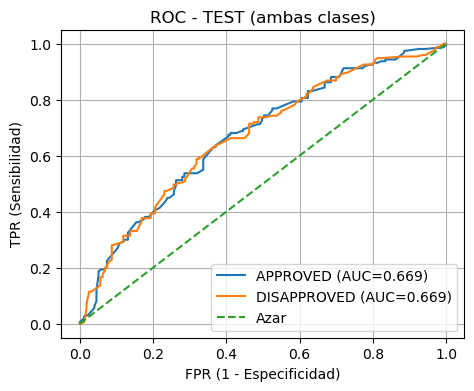

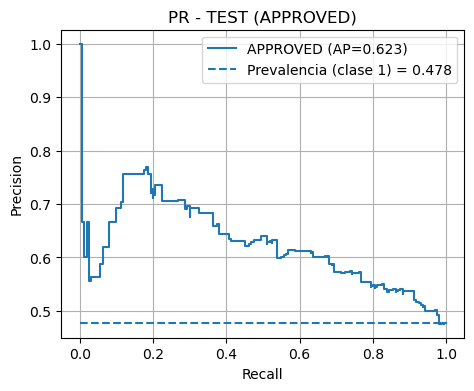

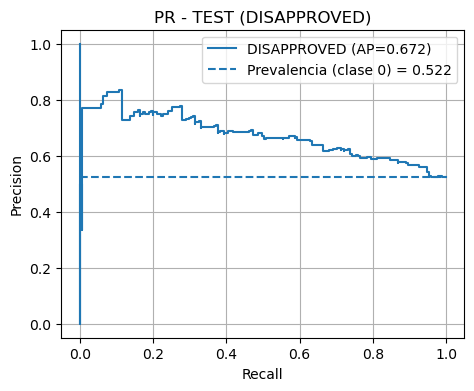

In [11]:
# === Curvas ROC y PR para ambas clases (APPROVED=1 y DISAPPROVED=0) ===
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probabilidades por clase
proba = winner_pipe.predict_proba(X_test)
proba1 = proba[:, 1]  # P(APPROVED=1 | x)
proba0 = proba[:, 0]  # P(DISAPPROVED=0 | x)

y_true = np.asarray(y_test)

# -------- ROC --------
# Clase 1 (APPROVED)
fpr1, tpr1, _ = roc_curve(y_true, proba1)
roc_auc1 = auc(fpr1, tpr1)

# Clase 0 (DISAPPROVED): hacemos positiva a la clase 0
y_true0 = 1 - y_true
fpr0, tpr0, _ = roc_curve(y_true0, proba0)
roc_auc0 = auc(fpr0, tpr0)

plt.figure(figsize=(5.2, 4))
plt.plot(fpr1, tpr1, label=f"APPROVED (AUC={roc_auc1:.3f})")
plt.plot(fpr0, tpr0, label=f"DISAPPROVED (AUC={roc_auc0:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Azar")
plt.xlabel("FPR (1 - Especificidad)")
plt.ylabel("TPR (Sensibilidad)")
plt.title("ROC - TEST (ambas clases)")
plt.legend()
plt.grid(True)
plt.show()

# -------- PR (Precision-Recall) --------
# Clase 1 (APPROVED)
prec1, rec1, _ = precision_recall_curve(y_true, proba1)
ap1 = average_precision_score(y_true, proba1)
prev1 = y_true.mean()  # prevalencia de clase 1

plt.figure(figsize=(5.2, 4))
plt.step(rec1, prec1, where="post", label=f"APPROVED (AP={ap1:.3f})")
plt.hlines(prev1, 0, 1, linestyles="--", label=f"Prevalencia (clase 1) = {prev1:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR - TEST (APPROVED)")
plt.legend()
plt.grid(True)
plt.show()

# Clase 0 (DISAPPROVED) como positiva
prec0, rec0, _ = precision_recall_curve(y_true0, proba0)
ap0 = average_precision_score(y_true0, proba0)
prev0 = y_true0.mean()  # = 1 - prev1

plt.figure(figsize=(5.2, 4))
plt.step(rec0, prec0, where="post", label=f"DISAPPROVED (AP={ap0:.3f})")
plt.hlines(prev0, 0, 1, linestyles="--", label=f"Prevalencia (clase 0) = {prev0:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR - TEST (DISAPPROVED)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# =========================================
# 10) Interpretabilidad + breve error analysis (pendiente)
# =========================================
# TODO: añadir (según modelo):
#  - Importancias (Permutation Importance) o Coeficientes (LogReg) / SHAP.
#  - Listar 10 FP y 10 FN con sus principales features para análisis.


In [13]:
# =========================================
# 11) Exportar artefactos (mínimo)
# =========================================
import sklearn
version_id = "v1"  # o datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
ART_DIR = os.path.join("artefactos", version_id)
os.makedirs(ART_DIR, exist_ok=True)

# Pipeline
pipe_path = os.path.join(ART_DIR, f"pipeline_{winner_name}.joblib")
joblib.dump(winner_pipe, pipe_path)

# Esquema y mapa de etiquetas
schema = {c: str(X[c].dtype) for c in X.columns}
json.dump(schema, open(os.path.join(ART_DIR, "input_schema.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)
json.dump({"DISAPPROVED":0,"APPROVED":1}, open(os.path.join(ART_DIR, "label_map.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)

# Política de decisión (usa BEST_THR provisional)
from sklearn.metrics import f1_score, precision_score, recall_score
def pack_metrics(y_true, proba, thr):
    yp = (proba >= thr).astype(int)
    return {
        "f1": float(f1_score(y_true, yp)),
        "precision": float(precision_score(y_true, yp, zero_division=0)),
        "recall": float(recall_score(y_true, yp)),
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "pr_auc": float(average_precision_score(y_true, proba)),
        "confusion_matrix": confusion_matrix(y_true, yp).tolist()
    }
decision = {
    "winner": winner_name,
    "threshold": float(BEST_THR),
    "test_metrics": pack_metrics(y_test, proba_test, BEST_THR)
}
json.dump(decision, open(os.path.join(ART_DIR, "decision_policy.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)

# Model Card mínima
model_card_md = f"""# Model Card — {winner_name}
**Versión:** {version_id}  
**Sistema:** Python {platform.python_version()}, scikit-learn {sklearn.__version__}

## Datos
Archivo: `{DATA_FILE}` | Shape: {X.shape} | Objetivo: `{TARGET}` (DISAPPROVED=0, APPROVED=1) | Prevalencia: {y.mean():.3f}

## Entrenamiento
Split 80/20 estratificado (random_state={RANDOM_STATE}). Preprocesamiento: StandardScaler (num) + OneHotEncoder(ignore) (cat) + SMOTE(k=3).

## Modelo
Seleccionado para TEST: **{winner_name}**.  
Umbral de decisión: **{BEST_THR:.2f}** (provisional).

## Métricas en TEST
F1={decision['test_metrics']['f1']:.3f}, P={decision['test_metrics']['precision']:.3f}, R={decision['test_metrics']['recall']:.3f},
ROC-AUC={decision['test_metrics']['roc_auc']:.3f}, PR-AUC={decision['test_metrics']['pr_auc']:.3f}.
"""
open(os.path.join(ART_DIR,"model_card.md"),"w",encoding="utf-8").write(model_card_md)

# Ejemplos de entrada (5 primeros de TEST)
json.dump(X_test.iloc[:5].to_dict(orient="records"),
          open(os.path.join(ART_DIR,"sample_inputs.json"),"w",encoding="utf-8"),
          ensure_ascii=False, indent=2)

print(f"Artefactos guardados en: {ART_DIR}")


Artefactos guardados en: artefactos/v1


In [14]:
# =========================================
# 12) Cargar artefactos y servir inferencia (mínimo)
# =========================================
import json, pandas as pd, numpy as np

ART_DIR = os.path.join("artefactos","v1")   # ajusta si cambias versión
INPUT_SCHEMA = json.load(open(os.path.join(ART_DIR,"input_schema.json"),"r",encoding="utf-8"))
LABEL_MAP    = json.load(open(os.path.join(ART_DIR,"label_map.json"),"r",encoding="utf-8"))
POLICY       = json.load(open(os.path.join(ART_DIR,"decision_policy.json"),"r",encoding="utf-8"))

WINNER    = POLICY["winner"]
THRESHOLD = float(POLICY.get("threshold", 0.5))
PIPE      = joblib.load(os.path.join(ART_DIR, f"pipeline_{WINNER}.joblib"))
REV_LABEL = {v:k for k,v in LABEL_MAP.items()}
FEATURES  = list(INPUT_SCHEMA.keys())

def _coerce_and_align(df):
    for c,t in INPUT_SCHEMA.items():
        if c not in df.columns: df[c]=np.nan
        if str(t).startswith(("int","float")): df[c]=pd.to_numeric(df[c], errors="coerce")
        elif str(t).lower() in ("bool","boolean"): df[c]=df[c].astype("bool")
        else: df[c]=df[c].astype("string")
    return df[FEATURES]

def predict_batch(records, thr=None):
    thr = THRESHOLD if thr is None else float(thr)
    if isinstance(records, dict): records=[records]
    df = _coerce_and_align(pd.DataFrame(records))
    p  = PIPE.predict_proba(df)[:,1]
    y  = (p>=thr).astype(int)
    return [{"proba":float(pi), "pred_int":int(yi), "pred_label":REV_LABEL[int(yi)], "threshold":thr}
            for pi,yi in zip(p,y)]

# Smoke mínimo con los samples exportados
SAMPLES_JSON = os.path.join(ART_DIR,"sample_inputs.json")
if os.path.exists(SAMPLES_JSON):
    samples = json.load(open(SAMPLES_JSON,"r",encoding="utf-8"))
    print(predict_batch(samples)[:3])


[{'proba': 0.907216694375192, 'pred_int': 1, 'pred_label': 'APPROVED', 'threshold': 0.5}, {'proba': 0.6185504437020021, 'pred_int': 1, 'pred_label': 'APPROVED', 'threshold': 0.5}, {'proba': 0.4462105246055245, 'pred_int': 0, 'pred_label': 'DISAPPROVED', 'threshold': 0.5}]


In [15]:
payload_one = { k: (0 if str(t).startswith(("int","float")) else ("",)[0]) for k,t in INPUT_SCHEMA.items() }
payload_one

{'Vehicle type': '', 'Fuel type': '', 'Vehicle age': 0}

In [19]:
samples_json = """
[
  {"Vehicle type": "PRIVATE",     "Fuel type": "BI-GLP", "Vehicle age": 2},
  {"Vehicle type": "INDEPENDENT", "Fuel type": "BI-GNV", "Vehicle age": 15},
  {"Vehicle type": "INDEPENDENT", "Fuel type": "BI-GNV", "Vehicle age": 25},
  {"Vehicle type": "STATION",     "Fuel type": "BI-GNV", "Vehicle age": 1},
  {"Vehicle type": "INDEPENDENT", "Fuel type": "BI-GNV", "Vehicle age": 3}
]
""".strip()

import json
samples_from_json = json.loads(samples_json)
res = predict_batch(samples_from_json)
res

[{'proba': 0.907216694375192,
  'pred_int': 1,
  'pred_label': 'APPROVED',
  'threshold': 0.5},
 {'proba': 0.6185504437020021,
  'pred_int': 1,
  'pred_label': 'APPROVED',
  'threshold': 0.5},
 {'proba': 0.4462105246055245,
  'pred_int': 0,
  'pred_label': 'DISAPPROVED',
  'threshold': 0.5},
 {'proba': 0.7600584408087709,
  'pred_int': 1,
  'pred_label': 'APPROVED',
  'threshold': 0.5},
 {'proba': 0.6376937430187557,
  'pred_int': 1,
  'pred_label': 'APPROVED',
  'threshold': 0.5}]